# Chapter 1 - Introduction

For this practice, we will use the following dataset:

- **dataset_profesor.csv**: synthetic dataset containing several variables.

The main package for machine learning in Python is **scikit-learn**.

Further reading:
- [scikit-learn](https://scikit-learn.org)

In addition, we will be using the following libraries:
- Data management
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)

- Plotting
    - [matplotlib](https://matplotlib.org/)


## 0. Import libraries and dataset

In [ ]:
from pathlib import Path
DATASET_PATH = Path("XXX/dataset_profesor.csv")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

def class_distribution(*series, names):
    table = []
    for name, s in zip(names, series):
        counts = s.value_counts().reindex([0, 1], fill_value=0)
        table.append({
            "split": name,
            "retained_0": counts.loc[0],
            "churn_1": counts.loc[1],
            "total": len(s),
        })
    return pd.DataFrame(table)


df = pd.read_csv(DATASET_PATH)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 47


## 1.  First look at the dataset

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tenure_months,120.0,NaN,NaN,NaN,36.708333,19.820368,2.0,20.0,36.5,54.0,71.0
monthly_spend,120.0,NaN,NaN,NaN,53.541667,9.855661,30.7,47.4,53.05,60.75,74.4
support_tickets_3m,120.0,NaN,NaN,NaN,1.458333,1.505708,0.0,0.0,1.0,2.0,9.0
usage_change_last_month,120.0,NaN,NaN,NaN,-0.011833,0.142133,-0.42,-0.09,0.01,0.08,0.29
late_payments_6m,120.0,NaN,NaN,NaN,0.283333,0.552813,0.0,0.0,0.0,0.0,2.0
churn_next_month,120.0,NaN,NaN,NaN,0.2,0.401677,0.0,0.0,0.0,0.0,1.0
cancellation_request_registered,120.0,NaN,NaN,NaN,0.2,0.401677,0.0,0.0,0.0,0.0,1.0
customer_id,120,120,C0000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


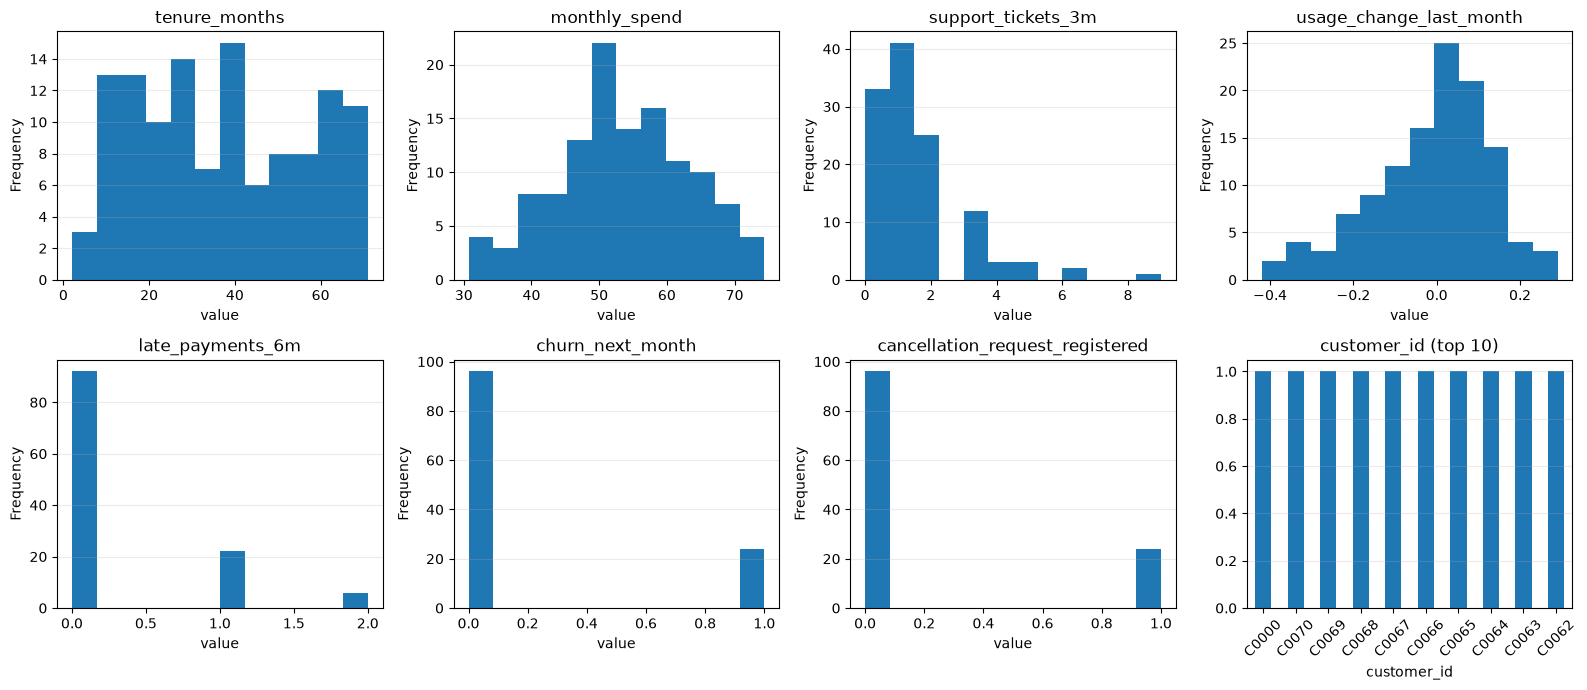

In [4]:
# Resumen estadístico del dataset.
display(df.describe(include="all").T)

# Valores más frecuentes de cada columna y distribución rápida.
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for ax, column in zip(axes, df.columns):
    if pd.api.types.is_numeric_dtype(df[column]):
        df[column].plot(kind="hist", bins=12, ax=ax, title=column)
        ax.set_xlabel("value")
    else:
        df[column].value_counts().head(10).plot(kind="bar", ax=ax, title=f"{column} (top 10)")
        ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 2. What is our objective?

In [ ]:
feature_columns = [
    "tenure_months",
    "monthly_spend",
    "support_tickets_3m",
    "usage_change_last_month",
    "late_payments_6m",
]
target_column = "churn_next_month"
leakage_column = "cancellation_request_registered"

## 3. First model training


In [ ]:
X = df[feature_columns]
y = df[target_column]
model_full_dataset = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_full_dataset.fit(X, y)

prediction = model_full_dataset.predict(X)
full_dataset_accuracy = accuracy_score(
    y, prediction
)
print(f"Accuracy training and testing over the same dataset: {full_dataset_accuracy:.0%}")


Accuracy training and testing over the same dataset: 100%


## 4. The first split: train and test

In [7]:
X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

model = DecisionTreeClassifier(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))


print(f"Accuracy over train dataset: {train_acc:.0%}")
print(f"Accuracy over test dataset: {test_acc:.0%}")


Accuracy over train dataset: 100%
Accuracy over test dataset: 0%


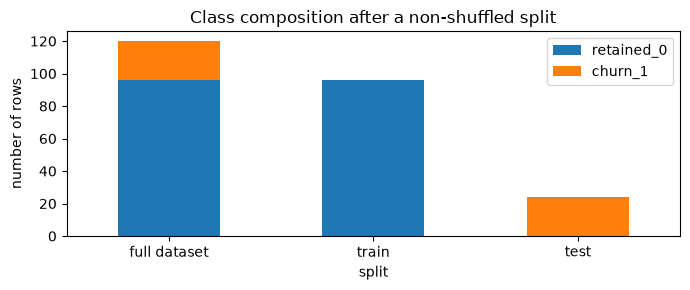

In [8]:
distribution = class_distribution(
    y, y_train, y_test,
    names=["full dataset", "train", "test"]
)

ax = distribution.set_index("split")[["retained_0", "churn_1"]].plot(
    kind="bar",
    stacked=True,
    figsize=(7, 3),
    rot=0,
    title="Class composition after a non-shuffled split"
)
ax.set_ylabel("number of rows")
plt.tight_layout()
plt.show()


## 4.2 A stratified split


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y
)


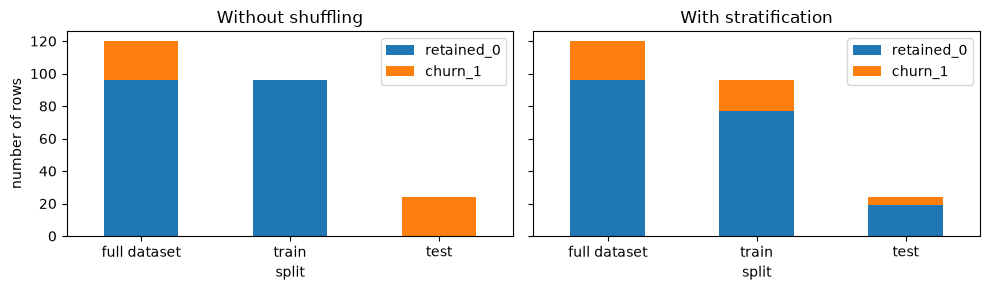

In [10]:
stratified_distribution = class_distribution(
    y, y_train, y_test,
    names=["full dataset", "train", "test"]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

distribution.set_index("split")[["retained_0", "churn_1"]].plot(
    kind="bar", stacked=True, ax=axes[0], rot=0, title="Without shuffling"
)
stratified_distribution.set_index("split")[["retained_0", "churn_1"]].plot(
    kind="bar", stacked=True, ax=axes[1], rot=0, title="With stratification"
)

for ax in axes:
    ax.set_ylabel("number of rows")

plt.tight_layout()
plt.show()


In [11]:
model = DecisionTreeClassifier(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Accuracy over train dataset: {train_acc:.0%}")
print(f"Accuracy over test dataset: {test_acc:.0%}")


Accuracy over train dataset: 100%
Accuracy over test dataset: 100%


## 5. What if we perform multiple tests?

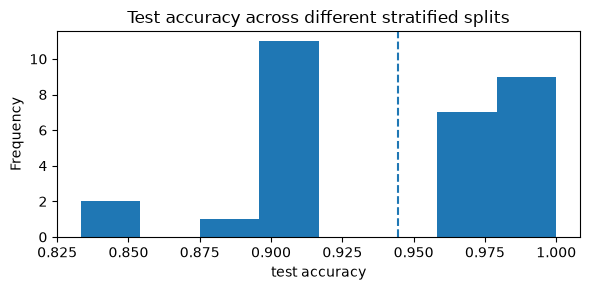

In [12]:
split_scores = []

for seed in range(30):
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed,
        shuffle=True,
        stratify=y
    )
    model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    model.fit(X_train_s, y_train_s)
    split_scores.append(accuracy_score(y_test_s, model.predict(X_test_s)))

split_scores_df = pd.DataFrame({"seed": range(30), "test_accuracy": split_scores})
ax = split_scores_df["test_accuracy"].plot(
    kind="hist",
    bins=8,
    figsize=(6, 3),
    title="Test accuracy across different stratified splits"
)
ax.axvline(split_scores_df["test_accuracy"].mean(), linestyle="--")
ax.set_xlabel("test accuracy")
plt.tight_layout()
plt.show()



## 6. Cross-validation

```text
Fold 1:  TEST  | TRAIN | TRAIN | TRAIN | TRAIN
Fold 2:  TRAIN | TEST  | TRAIN | TRAIN | TRAIN
Fold 3:  TRAIN | TRAIN | TEST  | TRAIN | TRAIN
Fold 4:  TRAIN | TRAIN | TRAIN | TEST  | TRAIN
Fold 5:  TRAIN | TRAIN | TRAIN | TRAIN | TEST
```

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

cv_results = pd.DataFrame({
    "fold": np.arange(1, len(cv_scores) + 1),
    "accuracy": cv_scores
})
cv_results


,fold,accuracy
0,1,0.875000
1,2,0.916667
2,3,0.958333
3,4,0.958333
4,5,0.958333


In [14]:
pd.DataFrame({
    "mean_accuracy": [cv_scores.mean()],
    "std_across_folds": [cv_scores.std()]
})


,mean_accuracy,std_across_folds
0,0.933333,0.033333


## 7. Leakage: a result that looks too good

In [15]:
X_valid = df[feature_columns]
X_with_leakage = df[feature_columns + [leakage_column]]
y = df[target_column]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

valid_scores = cross_val_score(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_valid,
    y,
    cv=cv,
    scoring="accuracy"
)

leakage_scores = cross_val_score(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_with_leakage,
    y,
    cv=cv,
    scoring="accuracy"
)

print(f"Accuracy for the valid dataset: {valid_scores.mean():.0%}")
print(f"Accuracy for the dataset with data leakage: {leakage_scores.mean():.0%}")


Accuracy for the valid dataset: 93%
Accuracy for the dataset with data leakage: 100%


## 8. Leakage 2: preprocessing belongs inside the evaluation loop

In [16]:
# KO
scaler = StandardScaler()
X_scaled_before_cv = scaler.fit_transform(X_valid)

scores_scaled_before_cv = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_scaled_before_cv,
    y,
    cv=cv,
    scoring="accuracy"
)

# OK
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline_scores = cross_val_score(
    pipe,
    X_valid,
    y,
    cv=cv,
    scoring="accuracy"
)

preprocessing_comparison = pd.DataFrame({
    "method": ["Scaling before CV (bad)", "Pipeline inside CV (good)"],
    "mean_cv_accuracy": [scores_scaled_before_cv.mean(), pipeline_scores.mean()],
    "std_across_folds": [scores_scaled_before_cv.std(), pipeline_scores.std()],
})
display(preprocessing_comparison)


,method,mean_cv_accuracy,std_across_folds
0,Scaling before CV (bad),0.983333,0.020412
1,Pipeline inside CV (good),0.975000,0.020412
